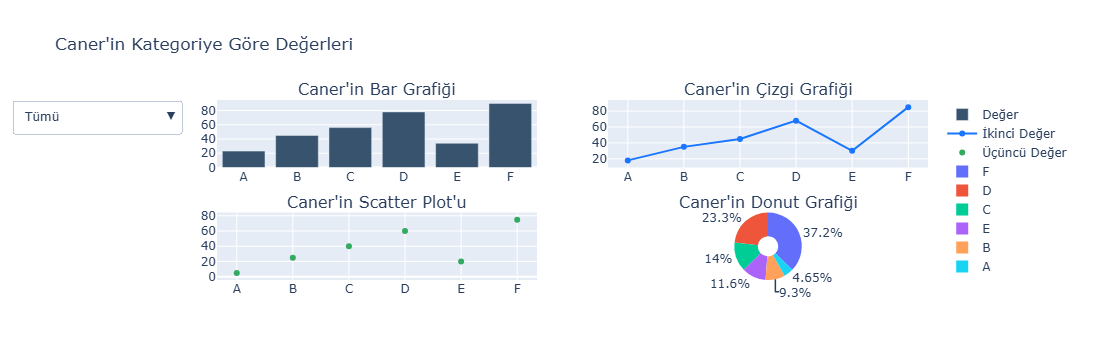

In [6]:
import plotly.graph_objs as go
import plotly.express as px
import pandas as pd
from plotly.subplots import make_subplots

# Örnek veri
df = pd.DataFrame({
    'Kategori': ['A', 'B', 'C', 'D', 'E', 'F'],
    'Değer': [23, 45, 56, 78, 34, 90],
    'İkinci Değer': [18, 35, 45, 68, 30, 85],
    'Üçüncü Değer': [5, 25, 40, 60, 20, 75],
    'Dördüncü Değer': [10, 20, 30, 50, 25, 80]
})

# Alt grafik oluşturma
fig = make_subplots(
    rows=2, cols=2, 
    subplot_titles=("Caner'in Bar Grafiği", "Caner'in Çizgi Grafiği", "Caner'in Scatter Plot'u", "Caner'in Donut Grafiği"),
    specs=[[{"type": "xy"}, {"type": "xy"}], [{"type": "xy"}, {"type": "domain"}]]
)

# Bar grafiği
bar_trace = go.Bar(
    x=df['Kategori'],
    y=df['Değer'],
    name='Değer',
    marker=dict(color='rgb(55, 83, 109)')
)

# Çizgi grafiği
line_trace = go.Scatter(
    x=df['Kategori'],
    y=df['İkinci Değer'],
    name='İkinci Değer',
    line=dict(color='rgb(26, 118, 255)'),
    mode='lines+markers'
)

# Scatter plot
scatter_trace = go.Scatter(
    x=df['Kategori'],
    y=df['Üçüncü Değer'],
    name='Üçüncü Değer',
    marker=dict(color='rgb(50, 171, 96)'),
    mode='markers'
)

# Donut grafiği
donut_trace = go.Pie(
    labels=df['Kategori'],
    values=df['Dördüncü Değer'],
    name='Dördüncü Değer',
    hole=.3
)

# Grafik düzeni
fig.add_trace(bar_trace, row=1, col=1)
fig.add_trace(line_trace, row=1, col=2)
fig.add_trace(scatter_trace, row=2, col=1)
fig.add_trace(donut_trace, row=2, col=2)

fig.update_layout(
    title_text="Caner'in Kategoriye Göre Değerleri",
    hovermode='closest',
    showlegend=True
)

# Kategorilere göre filtreleme ekleme
fig.update_layout(
    updatemenus=[
        dict(
            buttons=list([
                dict(label='Tümü',
                     method='update',
                     args=[{'visible': [True, True, True, True]}]),
                dict(label='Sadece Bar Grafiği',
                     method='update',
                     args=[{'visible': [True, False, False, False]}]),
                dict(label='Sadece Çizgi Grafiği',
                     method='update',
                     args=[{'visible': [False, True, False, False]}]),
                dict(label='Sadece Scatter Plot',
                     method='update',
                     args=[{'visible': [False, False, True, False]}]),
                dict(label='Sadece Donut Grafiği',
                     method='update',
                     args=[{'visible': [False, False, False, True]}])
            ]),
            direction='down',
        )
    ]
)

# Grafik Gösterme
fig.show()
